# Crop `IcelandDEM_20m.grd` by geographic extent

This notebook:

1. reads the original GMT grid metadata,
2. plots a downsampled preview of the full DEM,
3. plots the original geographic extent,
4. extracts a smaller lon/lat subset in memory,
5. plots the cropped DEM,
6. prepares an output path without saving anything yet.

Adjust the subset bounds in the parameter cell before running the crop cells.

In [19]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
from netCDF4 import Dataset

dem_path = Path('/raid2/jam247/JVGR_ASKJA/gmt_data/IcelandDEM_20m.grd')
output_path = dem_path.with_name('IcelandDEM_20m_subset.grd')

# Slightly larger than: region=-17.3/-15.9/64.845/65.35
# Edit these four values to choose a different crop window.
subset_lon_min = -17.4
subset_lon_max = -15.8
subset_lat_min = 64.8
subset_lat_max = 65.4


In [20]:
with Dataset(dem_path) as ds:
    lon_min, lon_max = ds.variables['x_range'][:]
    lat_min, lat_max = ds.variables['y_range'][:]
    dx, dy = ds.variables['spacing'][:]
    nx, ny = ds.variables['dimension'][:].astype(int)
    z_min, z_max = ds.variables['z_range'][:]
    fill_value = np.float32(-3.4028235e38)

lon = lon_min + np.arange(nx) * dx
lat = lat_min + np.arange(ny) * dy

# The GMT grid is stored row-by-row from north to south.
# Keep a separate latitude vector that matches the on-disk row order.
row_lat = lat_max - np.arange(ny) * dy

full_extent = {
    'lon_min': float(lon_min),
    'lon_max': float(lon_max),
    'lat_min': float(lat_min),
    'lat_max': float(lat_max),
    'dx': float(dx),
    'dy': float(dy),
    'nx': int(nx),
    'ny': int(ny),
    'z_min': float(z_min),
    'z_max': float(z_max),
}

full_extent

{'lon_min': -24.743784889738127,
 'lon_max': -13.189551126444352,
 'lat_min': 63.210427791558274,
 'lat_max': 66.56747788906226,
 'dx': 0.0004224582728809424,
 'dy': 0.00017931044212712245,
 'nx': 27350,
 'ny': 18722,
 'z_min': 0.0,
 'z_max': 2107.338134765625}

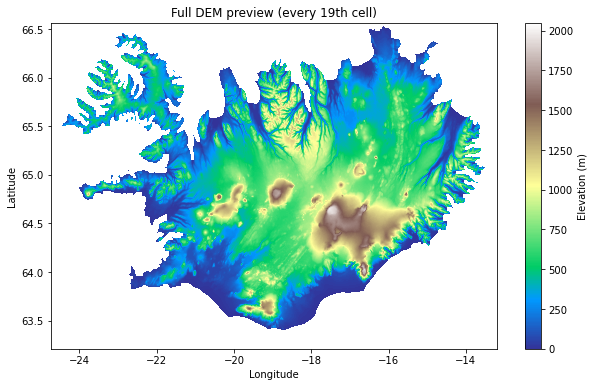

In [21]:
# Plot a downsampled preview of the full DEM so the entire raster is visible
# without loading the full-resolution grid into memory.
preview_max_dim = 1500
preview_stride = max(1, int(np.ceil(max(nx, ny) / preview_max_dim)))

preview_lon = lon[::preview_stride]
preview_lat = lat[::preview_stride]

with Dataset(dem_path) as ds:
    z = ds.variables['z']
    preview_rows = []
    for row in range(0, ny, preview_stride):
        start = row * nx
        stop = start + nx
        preview_rows.append(z[start:stop:preview_stride])

preview_data = np.vstack(preview_rows).astype(np.float32)
preview_data[preview_data <= fill_value / 2] = np.nan
preview_data_plot = np.flipud(preview_data)

fig, ax = plt.subplots(figsize=(10, 6))
image = ax.imshow(
    preview_data_plot,
    extent=[preview_lon.min(), preview_lon.max(), preview_lat.min(), preview_lat.max()],
    origin='lower',
    cmap='terrain',
    aspect='auto',
)
ax.set_xlabel('Longitude')
ax.set_ylabel('Latitude')
ax.set_title(f'Full DEM preview (every {preview_stride}th cell)')
fig.colorbar(image, ax=ax, label='Elevation (m)')
plt.show()

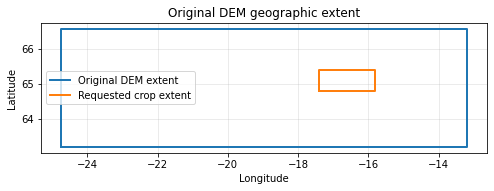

In [22]:
fig, ax = plt.subplots(figsize=(8, 8))
ax.plot(
    [full_extent['lon_min'], full_extent['lon_max'], full_extent['lon_max'], full_extent['lon_min'], full_extent['lon_min']],
    [full_extent['lat_min'], full_extent['lat_min'], full_extent['lat_max'], full_extent['lat_max'], full_extent['lat_min']],
    linewidth=2,
    label='Original DEM extent',
)
ax.plot(
    [subset_lon_min, subset_lon_max, subset_lon_max, subset_lon_min, subset_lon_min],
    [subset_lat_min, subset_lat_min, subset_lat_max, subset_lat_max, subset_lat_min],
    linewidth=2,
    label='Requested crop extent',
)
ax.set_xlabel('Longitude')
ax.set_ylabel('Latitude')
ax.set_title('Original DEM geographic extent')
ax.set_aspect('equal', adjustable='box')
ax.legend()
ax.grid(True, alpha=0.3)
# plt.show()

In [23]:
if not (full_extent['lon_min'] <= subset_lon_min < subset_lon_max <= full_extent['lon_max']):
    raise ValueError('Subset longitudes must fall inside the DEM extent.')

if not (full_extent['lat_min'] <= subset_lat_min < subset_lat_max <= full_extent['lat_max']):
    raise ValueError('Subset latitudes must fall inside the DEM extent.')

x0 = int(np.searchsorted(lon, subset_lon_min, side='left'))
x1 = int(np.searchsorted(lon, subset_lon_max, side='right'))
y_rows = np.where((row_lat >= subset_lat_min) & (row_lat <= subset_lat_max))[0]

if y_rows.size == 0:
    raise ValueError('Requested latitude range does not overlap the DEM rows.')

y0 = int(y_rows.min())
y1 = int(y_rows.max()) + 1

subset_lon = lon[x0:x1]
subset_lat = row_lat[y0:y1][::-1]

with Dataset(dem_path) as ds:
    z = ds.variables['z']
    row_slices = []
    for row in range(y0, y1):
        start = row * nx + x0
        stop = row * nx + x1
        row_slices.append(z[start:stop])

subset_data = np.vstack(row_slices).astype(np.float32)
subset_data[subset_data <= fill_value / 2] = np.nan
subset_data_plot = np.flipud(subset_data)

subset_summary = {
    'shape': subset_data_plot.shape,
    'lon_min': float(subset_lon.min()),
    'lon_max': float(subset_lon.max()),
    'lat_min': float(subset_lat.min()),
    'lat_max': float(subset_lat.max()),
    'min_elevation_m': float(np.nanmin(subset_data_plot)),
    'max_elevation_m': float(np.nanmax(subset_data_plot)),
}

subset_summary

{'shape': (3347, 3787),
 'lon_min': -17.399770273975825,
 'lon_max': -15.800343252848576,
 'lat_min': 64.80001486101521,
 'lat_max': 65.39998760037257,
 'min_elevation_m': 240.0,
 'max_elevation_m': 1640.0}

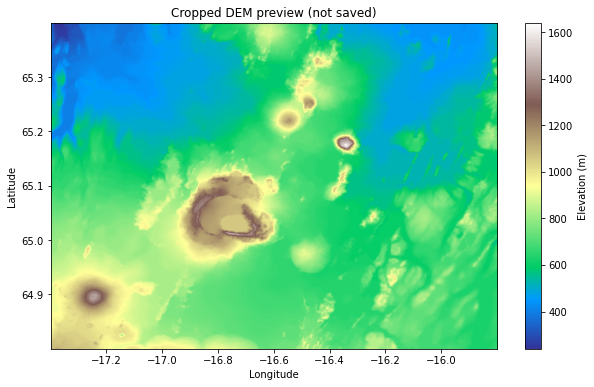

In [24]:
fig, ax = plt.subplots(figsize=(10, 6))
image = ax.imshow(
    subset_data_plot,
    extent=[subset_lon.min(), subset_lon.max(), subset_lat.min(), subset_lat.max()],
    origin='lower',
    cmap='terrain',
    aspect='auto',
)
ax.set_xlabel('Longitude')
ax.set_ylabel('Latitude')
ax.set_title('Cropped DEM preview (not saved)')
fig.colorbar(image, ax=ax, label='Elevation (m)')
plt.show()

In [25]:
# Export the cropped DEM in GMT/netCDF grid format.
# `subset_data` is kept in the on-disk north-to-south row order expected by GMT.
export_data = np.where(np.isnan(subset_data), fill_value, subset_data).astype(np.float32)

with Dataset(output_path, 'w', format='NETCDF3_CLASSIC') as out_ds:
    out_ds.createDimension('side', 2)
    out_ds.createDimension('xysize', export_data.size)

    x_range_var = out_ds.createVariable('x_range', 'f8', ('side',))
    y_range_var = out_ds.createVariable('y_range', 'f8', ('side',))
    z_range_var = out_ds.createVariable('z_range', 'f8', ('side',))
    spacing_var = out_ds.createVariable('spacing', 'f8', ('side',))
    dimension_var = out_ds.createVariable('dimension', 'i4', ('side',))
    z_var = out_ds.createVariable('z', 'f4', ('xysize',), fill_value=fill_value)

    x_range_var[:] = [subset_lon.min(), subset_lon.max()]
    y_range_var[:] = [subset_lat.min(), subset_lat.max()]
    z_range_var[:] = [np.nanmin(subset_data), np.nanmax(subset_data)]
    spacing_var[:] = [dx, dy]
    dimension_var[:] = [len(subset_lon), len(subset_lat)]
    z_var[:] = export_data.ravel()

    x_range_var.units = 'meters'
    y_range_var.units = 'meters'
    z_range_var.units = 'meters'
    z_var.scale_factor = 1.0
    z_var.add_offset = 0.0
    z_var.node_offset = 1

output_path

PosixPath('/raid2/jam247/JVGR_ASKJA/gmt_data/IcelandDEM_20m_subset.grd')